<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/ReinforcementLearningAndDecisionMaking/ReinforcementLearningAndDecisionMaking/Reward_Shaping_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

In [2]:
# --- CONFIG ---
TICKER = "NVDA"
START = "2015-01-01"
END = "2024-01-01"
WINDOW_SIZE = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# --- DATA LOADING ---
def get_data(ticker):
    df = yf.download(ticker, start=START, end=END, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Fill missing data to avoid NaNs
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    # Feature Engineering
    df['Returns'] = df['Close'].pct_change()
    df['Vol'] = df['Returns'].rolling(20).std()
    df.dropna(inplace=True)

    # Normalize for the Neural Network
    df['Norm_Close'] = df['Close'] / df['Close'].iloc[0]
    return df

df = get_data(TICKER)
print(f"✅ Data Loaded: {len(df)} rows.")

/tmp/ipython-input-2276643617.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


✅ Data Loaded: 2244 rows.


In [4]:
class ShapingEnv(gym.Env):
    def __init__(self, df, reward_func):
        super(ShapingEnv, self).__init__()
        self.df = df
        self.reward_func = reward_func # <--- The Magic Parameter
        self.action_space = spaces.Discrete(3) # Hold, Buy, Sell
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(WINDOW_SIZE, 5), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = WINDOW_SIZE
        self.balance = 10000
        self.shares = 0
        self.net_worth = 10000
        self.initial_worth = 10000
        self.history = [] # To track returns for Sharpe/Sortino calc
        return self._get_obs(), {}

    def _get_obs(self):
        # Simple Window: Close, Vol, Returns
        frame = self.df.iloc[self.current_step-WINDOW_SIZE : self.current_step]
        obs = frame[['Close', 'Vol', 'Returns']].values

        # Normalize Prices relative to window start
        obs[:, 0] = obs[:, 0] / obs[0, 0]
        obs_final = np.pad(obs, ((0,0), (0,2)), 'constant')
        # Add Portfolio State (Cash%, Shares?)
        # Padding to match shape or simply passing features
        # For simplicity, we just pass the market data here
        return obs_final.astype(np.float32) # <--- CRITICAL FIX

    def step(self, action):
        prev_worth = self.net_worth
        current_price = float(self.df.iloc[self.current_step]['Close'])

        # Execute Trade
        if action == 1 and self.balance > 0: # Buy
            self.shares = self.balance / current_price
            self.balance = 0
        elif action == 2 and self.shares > 0: # Sell
            self.balance = self.shares * current_price
            self.shares = 0

        self.current_step += 1

        # Calculate New Net Worth
        next_price = float(self.df.iloc[self.current_step]['Close'])
        self.net_worth = self.balance + (self.shares * next_price)

        # Calculate Raw Return (needed for history)
        step_return = (self.net_worth - prev_worth) / prev_worth
        self.history.append(step_return)

        # --- APPLY REWARD FUNCTION ---
        reward = self.reward_func(self.history)

        terminated = self.net_worth < 5000 # Stop if bust
        truncated = self.current_step >= len(self.df) - 5

        return self._get_obs(), reward, terminated, truncated, {'net_worth': self.net_worth}

In [5]:
# 1. The Greedy (Profit Only)
def reward_profit(history):
    return history[-1] * 100 # Just the raw return of the last step

# 2. The Balanced (Sharpe Ratio)
# Reward = Mean Return / Std Dev of Returns (Risk)
def reward_sharpe(history):
    if len(history) < 30: return 0 # Need data to calculate deviation
    window = np.array(history[-30:]) # Look at last 30 steps
    if window.std() == 0: return 0
    sharpe = window.mean() / window.std()
    return sharpe * 0.1 # Scale down because Sharpe can be large

# 3. The Safe (Sortino Ratio)
# Reward = Mean Return / Std Dev of NEGATIVE Returns (Downside Risk)
def reward_sortino(history):
    if len(history) < 30: return 0
    window = np.array(history[-30:])

    # Calculate Downside Deviation (only consider negative returns)
    negative_returns = window[window < 0]
    if len(negative_returns) == 0: downside_std = 0.01 # No risk!
    else: downside_std = negative_returns.std()

    sortino = window.mean() / (downside_std + 1e-6)
    return sortino * 0.1

In [6]:
class PPOAgent:
    def __init__(self, input_dim, action_dim):
        self.gamma = 0.99
        self.clip_ratio = 0.2
        # Initialize networks (Force them to float32 explicitly)
        self.actor = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(),
            nn.Linear(128, 3), nn.Softmax(dim=-1)
        ).float().to(DEVICE)

        self.critic = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(),
            nn.Linear(128, 1)
        ).float().to(DEVICE)

        self.optimizer = optim.Adam(list(self.actor.parameters()) + list(self.critic.parameters()), lr=0.0003)
        self.reset_memory()

    def reset_memory(self):
        self.states, self.actions, self.logprobs, self.rewards, self.dones = [], [], [], [], []

    def select_action(self, state):
        # Force input to float32
        state = torch.FloatTensor(state).float().flatten().unsqueeze(0).to(DEVICE)
        dist = Categorical(self.actor(state))
        action = dist.sample()
        return action.item(), dist.log_prob(action).item()

    def record(self, s, a, lp, r, d):
        # Force state to float32 immediately upon recording
        self.states.append(torch.tensor(s, dtype=torch.float32).flatten())
        self.actions.append(torch.tensor(a))
        self.logprobs.append(torch.tensor(lp))
        self.rewards.append(r)
        self.dones.append(d)

    def learn(self):
        if not self.states: return

        # 1. Convert lists to Tensors (STRICTLY FLOAT32)
        # Note: torch.stack expects tensors of same type
        states = torch.stack(self.states).to(DEVICE)
        actions = torch.stack(self.actions).to(DEVICE)
        old_logprobs = torch.stack(self.logprobs).to(DEVICE)

        # 2. Calculate Returns (Monte Carlo)
        returns = []
        discounted_sum = 0
        for reward, is_terminal in zip(reversed(self.rewards), reversed(self.dones)):
            if is_terminal: discounted_sum = 0
            discounted_sum = reward + (0.99 * discounted_sum)
            returns.insert(0, discounted_sum)

        # --- CRITICAL FIX: Force Returns to Float32 ---
        returns = torch.tensor(returns, dtype=torch.float32).to(DEVICE)

        # Normalize Returns (Safety)
        if returns.std() > 1e-5:
            returns = (returns - returns.mean()) / (returns.std() + 1e-7)
        else:
            returns = returns - returns.mean()

        # 3. Update Loop
        for _ in range(3):
            # Evaluate (Actor & Critic are float32, so inputs must be too)
            probs = self.actor(states)
            dist = Categorical(probs)
            new_logprobs = dist.log_prob(actions)
            entropy = dist.entropy().mean()

            # Critic Value
            state_values = self.critic(states).squeeze()

            # Ratios & Advantages
            ratio = torch.exp(new_logprobs - old_logprobs)

            # Ensure subtraction is float32 - float32
            advantages = returns - state_values.detach()

            # Loss Calculation
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 0.8, 1.2) * advantages

            loss = -torch.min(surr1, surr2) + 0.5 * nn.MSELoss()(state_values, returns) - 0.01 * entropy

            self.optimizer.zero_grad()
            loss.mean().backward()
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
            self.optimizer.step()

        self.reset_memory()

🧪 Starting Experiments on cpu...

Training Agent: Greedy (Profit)...
   -> Running Backtest Audit...

Training Agent: Balanced (Sharpe)...
   -> Running Backtest Audit...

Training Agent: Safe (Sortino)...
   -> Running Backtest Audit...

📊 REWARD SHAPING SHOWDOWN
         Strategy  Return Sharpe Sortino Max DD   Vol
  Greedy (Profit) 8759.2%   1.30    1.92 -66.3% 48.5%
Balanced (Sharpe) 8759.2%   1.30    1.92 -66.3% 48.5%
   Safe (Sortino)    0.0%   0.00    0.00   0.0%  0.0%


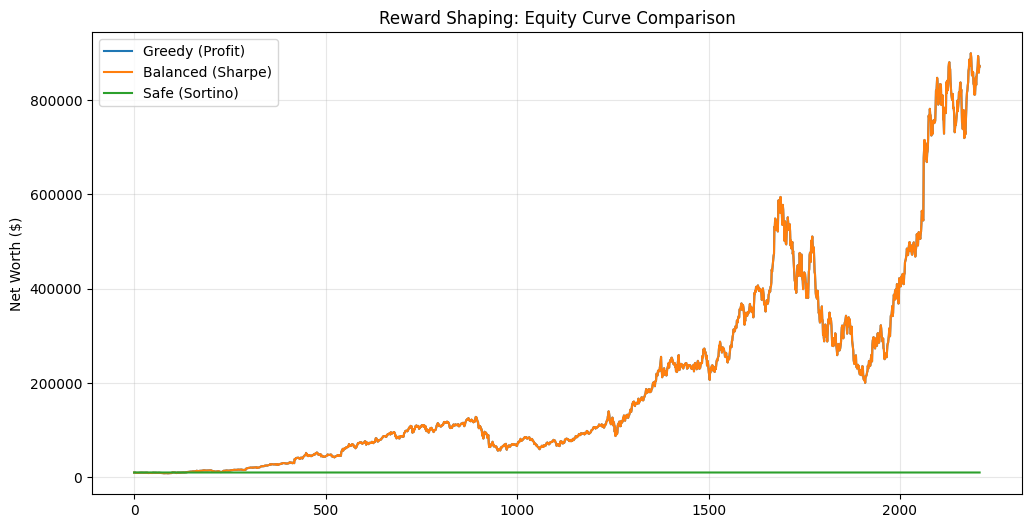

In [7]:
print(f"🧪 Starting Experiments on {DEVICE}...")

final_metrics = []
equity_curves = {}

# Re-define to ensure clean slate
experiments = {
    "Greedy (Profit)": reward_profit,
    "Balanced (Sharpe)": reward_sharpe,
    "Safe (Sortino)": reward_sortino
}

for name, func in experiments.items():
    print(f"\nTraining Agent: {name}...")

    # 1. SETUP
    env = ShapingEnv(df, reward_func=func)
    agent = PPOAgent(input_dim=WINDOW_SIZE*5, action_dim=3)

    # 2. TRAIN LOOP
    for ep in range(50):
        s, _ = env.reset()
        done = False
        while not done:
            # Force cast state coming from env
            s = s.astype(np.float32)

            a, lp = agent.select_action(s)
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc

            # Record transition
            agent.record(s, a, lp, r, done)
            s = ns

            if env.current_step % 1000 == 0:
                agent.learn()

    # 3. AUDIT LOOP
    print(f"   -> Running Backtest Audit...")
    audit_env = ShapingEnv(df, reward_func=func)
    state, _ = audit_env.reset()
    done = False
    curve = []

    while not done:
        with torch.no_grad():
            state_val = state.astype(np.float32)
            state_t = torch.FloatTensor(state_val).flatten().unsqueeze(0).to(DEVICE)
            action = torch.argmax(agent.actor(state_t)).item()

        state, _, term, trunc, info = audit_env.step(action)
        done = term or trunc
        curve.append(info['net_worth'])

    equity_curves[name] = curve

    # 4. METRICS
    strat = pd.Series(curve)
    returns = strat.pct_change().dropna()

    total_ret = (strat.iloc[-1] / strat.iloc[0]) - 1
    vol = returns.std() * np.sqrt(252) if len(returns) > 0 else 0
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if vol > 0 else 0

    neg_ret = returns[returns < 0]
    sortino = (returns.mean() / neg_ret.std()) * np.sqrt(252) if len(neg_ret) > 0 else 0

    cum_ret = (1 + returns).cumprod()
    peak = cum_ret.cummax()
    dd = (cum_ret - peak) / peak
    max_dd = dd.min() if len(dd) > 0 else 0

    final_metrics.append({
        "Strategy": name,
        "Return": f"{total_ret*100:.1f}%",
        "Sharpe": f"{sharpe:.2f}",
        "Sortino": f"{sortino:.2f}",
        "Max DD": f"{max_dd*100:.1f}%",
        "Vol": f"{vol*100:.1f}%"
    })

# --- OUTPUT ---
print("\n" + "="*60)
print("📊 REWARD SHAPING SHOWDOWN")
print("="*60)
metrics_df = pd.DataFrame(final_metrics)
print(metrics_df.to_string(index=False))
print("="*60)

# --- PLOT ---
plt.figure(figsize=(12, 6))
for name, curve in equity_curves.items():
    plt.plot(curve, label=name)
plt.title("Reward Shaping: Equity Curve Comparison")
plt.ylabel("Net Worth ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

🧪 Starting Experiments on cpu...

Training Greedy (Profit) Agent...
   -> Running Backtest Audit...

Training Balanced (Sharpe) Agent...
   -> Running Backtest Audit...

Training Safe (Sortino) Agent...
   -> Running Backtest Audit...

📊 REWARD SHAPING SHOWDOWN
         Strategy  Return Sharpe Sortino Max DD   Vol
  Greedy (Profit) 8759.2%   1.30    1.92 -66.3% 48.5%
Balanced (Sharpe)  192.1%   0.67    0.46 -27.7% 21.6%
   Safe (Sortino)    0.0%   0.00    0.00   0.0%  0.0%


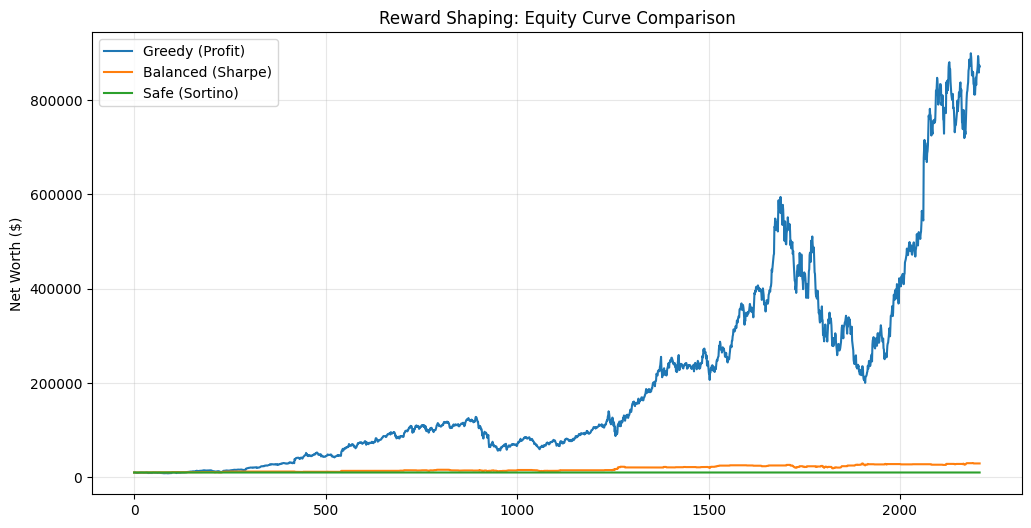

In [9]:
import pandas as pd
import scipy.stats as stats

# Define the Reward Functions (Just to ensure they are available)
def reward_profit(history): return history[-1] * 100
def reward_sharpe(history):
    return (np.mean(history[-30:]) / (np.std(history[-30:]) + 1e-6)) * 0.1 if len(history) >= 30 else 0
def reward_sortino(history):
    if len(history) < 30: return 0
    window = np.array(history[-30:])
    downside = window[window < 0]
    std_down = downside.std() if len(downside) > 0 else 0.01
    return (window.mean() / (std_down + 1e-6)) * 0.1

experiments = {
    "Greedy (Profit)": reward_profit,
    "Balanced (Sharpe)": reward_sharpe,
    "Safe (Sortino)": reward_sortino
}

final_metrics = []
equity_curves = {}

print(f"🧪 Starting Experiments on {DEVICE}...")

for name, func in experiments.items():
    print(f"\nTraining {name} Agent...")

    # 1. TRAIN
    # We train for 50 episodes to get basic behavior
    # In production, you'd want 200+
    env = ShapingEnv(df, reward_func=func)
    agent = PPOAgent(input_dim=WINDOW_SIZE*5, action_dim=3)

    for ep in range(50):
        s, _ = env.reset()
        done = False
        while not done:
            a, lp = agent.select_action(s)
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc
            agent.record(s, a, lp, r, done)
            s = ns
            if env.current_step % 1000 == 0: agent.learn() # Learn periodically

    # 2. AUDIT (Backtest Phase)
    print(f"   -> Running Backtest Audit...")
    audit_env = ShapingEnv(df, reward_func=func) # Same env, just for testing
    state, _ = audit_env.reset()
    done = False
    curve = []

    while not done:
        with torch.no_grad():
            state_t = torch.FloatTensor(state).flatten().unsqueeze(0).to(DEVICE)
            # Deterministic Action (Mode)
            action = torch.argmax(agent.actor(state_t)).item()

        state, _, term, trunc, info = audit_env.step(action)
        done = term or trunc
        curve.append(info['net_worth'])

    equity_curves[name] = curve

    # 3. CALCULATE METRICS
    strat = pd.Series(curve)
    returns = strat.pct_change().dropna()

    # CAGR
    total_ret = (strat.iloc[-1] / strat.iloc[0]) - 1
    cagr = (strat.iloc[-1] / strat.iloc[0]) ** (252/len(strat)) - 1

    # Volatility & Sharpe
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if vol > 0 else 0

    # Sortino (Downside Risk)
    neg_ret = returns[returns < 0]
    sortino = (returns.mean() / neg_ret.std()) * np.sqrt(252) if len(neg_ret) > 0 else 0

    # Max Drawdown
    cum_ret = (1 + returns).cumprod()
    peak = cum_ret.cummax()
    dd = (cum_ret - peak) / peak
    max_dd = dd.min()

    final_metrics.append({
        "Strategy": name,
        "Return": f"{total_ret*100:.1f}%",
        "Sharpe": f"{sharpe:.2f}",
        "Sortino": f"{sortino:.2f}",
        "Max DD": f"{max_dd*100:.1f}%",
        "Vol": f"{vol*100:.1f}%"
    })

# --- DISPLAY RESULTS ---
print("\n" + "="*60)
print("📊 REWARD SHAPING SHOWDOWN")
print("="*60)
metrics_df = pd.DataFrame(final_metrics)
print(metrics_df.to_string(index=False))
print("="*60)

# --- PLOT ---
plt.figure(figsize=(12, 6))
for name, curve in equity_curves.items():
    plt.plot(curve, label=name)
plt.title("Reward Shaping: Equity Curve Comparison")
plt.ylabel("Net Worth ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()